# Advanced Analytics + Risk Metrics
**Bluestock Fintech — Capstone Project I: Mutual Fund Analytics (Indian Market)**

This notebook covers the Advanced Analytics + Risk Metrics task:
1. Historical VaR / CVaR (95%) for all 40 schemes
2. Rolling 90-day Sharpe ratio for 5 key funds
3. Investor cohort analysis
4. SIP continuity analysis
5. Simple fund recommender
6. Sector concentration (HHI)
7. Advanced insights

Data source: `mutual_fund_analytics.db` — a SQLite star-schema database of
synthetic data anchored to realistic AMFI-style category return/volatility
profiles for the Indian mutual fund market.

## 0. Setup & Data Load

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

DB_PATH = "mutual_fund_analytics.db"
conn = sqlite3.connect(DB_PATH)

dim_fund = pd.read_sql("SELECT * FROM dim_fund", conn)
fact_nav = pd.read_sql("SELECT * FROM fact_nav", conn, parse_dates=["date"])
dim_investor = pd.read_sql("SELECT * FROM dim_investor", conn, parse_dates=["first_transaction_date"])
fact_txn = pd.read_sql("SELECT * FROM fact_transaction", conn, parse_dates=["date"])
fund_holdings = pd.read_sql("SELECT * FROM fund_holdings", conn)

print(f"Funds: {len(dim_fund)} | NAV rows: {len(fact_nav):,} | Investors: {len(dim_investor)} | Transactions: {len(fact_txn):,}")
dim_fund.head()

Funds: 40 | NAV rows: 31,280 | Investors: 650 | Transactions: 21,383


,fund_id,fund_name,amc,category,risk_grade,launch_date
0,1,UTI Bluechip Fund,UTI MF,Large Cap,Moderate,2015-04-01
1,2,Aditya Bluechip Fund,Aditya Birla SL MF,Large Cap,Moderate,2019-04-01
2,3,UTI Top 100 Fund,UTI MF,Large Cap,Moderate,2015-04-01
3,4,UTI Frontline Equity Fund,UTI MF,Large Cap,Moderate,2015-04-01
4,5,Aditya Bluechip Fund,Aditya Birla SL MF,Large Cap,Moderate,2017-04-01


## 1. Historical VaR & CVaR (95%)

- **VaR (95%)** = 5th percentile of the daily return distribution — the loss level not expected to be exceeded on 95% of days.
- **CVaR (95%)** (Expected Shortfall) = the mean of all returns *at or below* the VaR threshold — captures the severity of the tail, not just its edge.

Computed for all 40 schemes using their full ~3-year daily return history.

In [2]:
var_rows = []
for fid, grp in fact_nav.groupby("fund_id"):
    r = grp["daily_return"].values
    var_95 = np.percentile(r, 5)
    cvar_95 = r[r <= var_95].mean()
    var_rows.append({"fund_id": fid, "VaR_95": var_95, "CVaR_95": cvar_95})

var_df = (pd.DataFrame(var_rows)
          .merge(dim_fund[["fund_id", "fund_name", "category", "risk_grade"]], on="fund_id")
          [["fund_id", "fund_name", "category", "risk_grade", "VaR_95", "CVaR_95"]]
          .sort_values("VaR_95"))

var_df.to_csv("var_cvar_report.csv", index=False)
print("Saved var_cvar_report.csv")
var_df.head(10)

Saved var_cvar_report.csv


,fund_id,fund_name,category,risk_grade,VaR_95,CVaR_95
18,19,ICICI Micro Emerging Fund,Small Cap,High,-0.028911,-0.037961
17,18,Axis Small Cap Fund,Small Cap,High,-0.027469,-0.036166
16,17,Mirae Small Growth Fund,Small Cap,High,-0.025526,-0.039034
28,29,Aditya Technology Fund,Sectoral/Thematic,High,-0.025487,-0.035816
15,16,SBI Small Growth Fund,Small Cap,High,-0.025310,-0.036116
29,30,Mirae Technology Fund,Sectoral/Thematic,High,-0.024251,-0.033115
27,28,DSP Technology Fund,Sectoral/Thematic,High,-0.023986,-0.034576
14,15,Mirae Mid Growth Fund,Mid Cap,High,-0.023851,-0.035974
26,27,DSP Infrastructure Fund,Sectoral/Thematic,High,-0.023210,-0.033938
11,12,Franklin Mid Growth Fund,Mid Cap,High,-0.022540,-0.031238


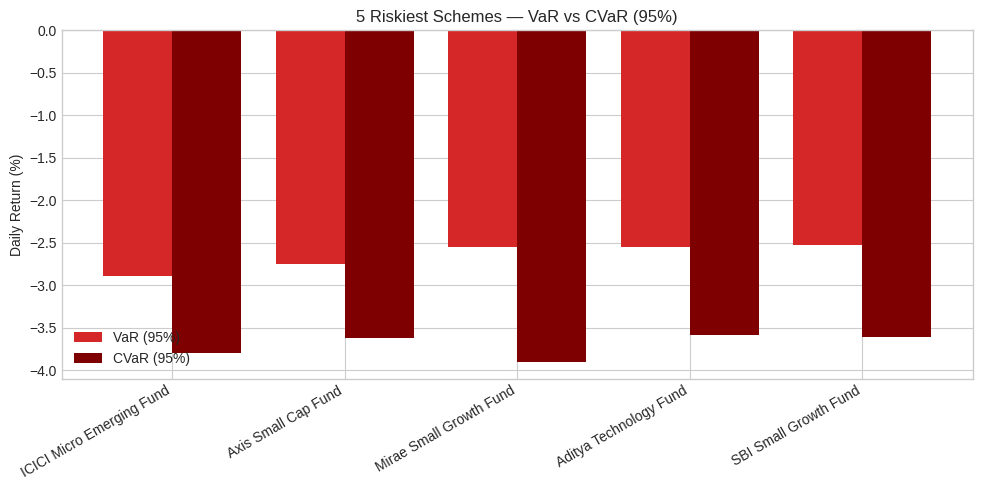

In [3]:
# 5 riskiest schemes by VaR
fig, ax = plt.subplots(figsize=(10, 5))
worst5 = var_df.head(5)
x = np.arange(len(worst5))
ax.bar(x - 0.2, worst5["VaR_95"]*100, width=0.4, label="VaR (95%)", color="#d62728")
ax.bar(x + 0.2, worst5["CVaR_95"]*100, width=0.4, label="CVaR (95%)", color="#7f0000")
ax.set_xticks(x)
ax.set_xticklabels(worst5["fund_name"], rotation=30, ha="right")
ax.set_ylabel("Daily Return (%)")
ax.set_title("5 Riskiest Schemes — VaR vs CVaR (95%)")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Rolling 90-Day Sharpe Ratio

Rolling Sharpe = `returns.rolling(90).mean() / returns.rolling(90).std() * sqrt(252)`,
computed on excess daily returns (over an assumed 6% p.a. risk-free rate),
plotted for 5 representative funds — one from each of 5 major categories.

   fund_id                       fund_name           category
0       38         SBI Corporate Bond Fund   Debt - Long Term
1       34        HDFC Short Duration Fund  Debt - Short Term
2       20              DSP Tax Saver Fund               ELSS
3        6      Aditya Dynamic Equity Fund          Flexi Cap
4       31  ICICI Conservative Hybrid Fund    Hybrid/Balanced


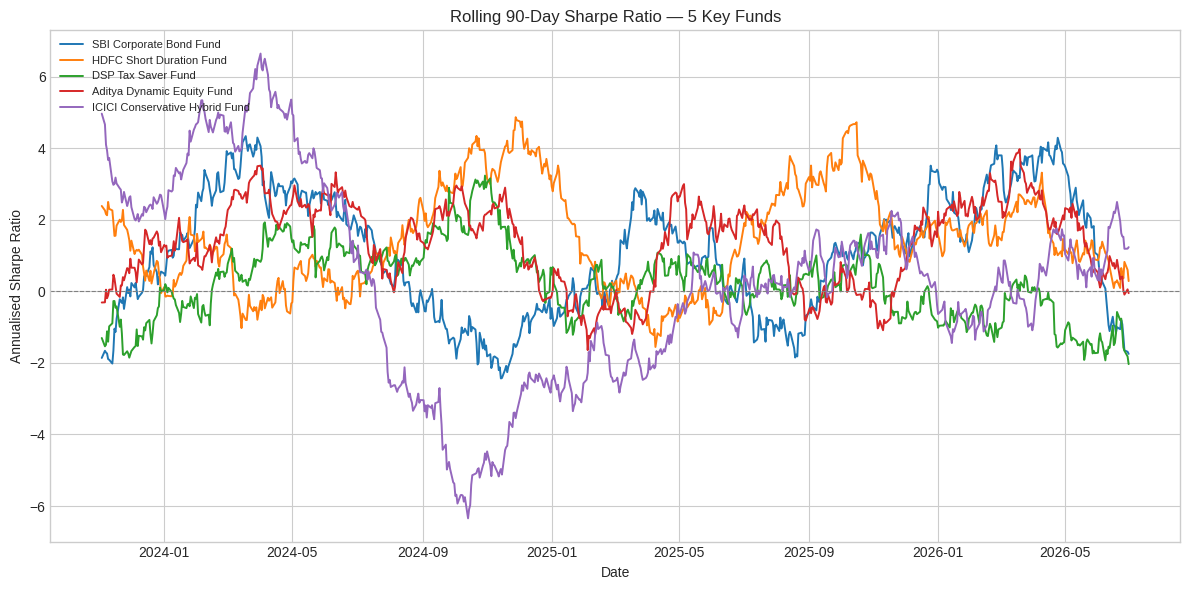

Saved rolling_sharpe_chart.png


In [4]:
key_funds = (dim_fund.sort_values("fund_id")
             .groupby("category").first()
             .reset_index()[["fund_id", "fund_name", "category"]]
             .head(5))
print(key_funds)

RF_DAILY = 0.06 / 252
fig, ax = plt.subplots(figsize=(12, 6))

for _, row in key_funds.iterrows():
    fid = row["fund_id"]
    s = fact_nav[fact_nav.fund_id == fid].sort_values("date").set_index("date")["daily_return"]
    excess = s - RF_DAILY
    roll_sharpe = (excess.rolling(90).mean() / s.rolling(90).std()) * np.sqrt(252)
    ax.plot(roll_sharpe.index, roll_sharpe.values, label=row["fund_name"], linewidth=1.4)

ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_title("Rolling 90-Day Sharpe Ratio — 5 Key Funds")
ax.set_xlabel("Date")
ax.set_ylabel("Annualised Sharpe Ratio")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("rolling_sharpe_chart.png", dpi=150)
plt.show()
print("Saved rolling_sharpe_chart.png")

## 3. Investor Cohort Analysis

Investors are grouped by the year of their first transaction. For each cohort
we compute the average SIP amount, total amount invested, number of investors,
and the most-preferred fund (by SIP transaction count).

In [5]:
dim_investor["cohort_year"] = dim_investor["first_transaction_date"].dt.year
txn_cohort = fact_txn.merge(dim_investor[["investor_id", "cohort_year"]], on="investor_id")
sip_txn = txn_cohort[txn_cohort.txn_type == "SIP"]

cohort_summary = sip_txn.groupby("cohort_year").agg(
    avg_sip_amount=("amount", "mean"),
    total_invested=("amount", "sum"),
    n_investors=("investor_id", "nunique"),
    n_sip_txns=("amount", "count"),
).reset_index()

top_fund = (sip_txn.merge(dim_fund[["fund_id", "fund_name"]], on="fund_id")
            .groupby(["cohort_year", "fund_name"]).size().reset_index(name="txn_count")
            .sort_values(["cohort_year", "txn_count"], ascending=[True, False])
            .groupby("cohort_year").first()[["fund_name", "txn_count"]]
            .rename(columns={"fund_name": "top_fund_preference"})
            .reset_index())

cohort_summary = cohort_summary.merge(top_fund, on="cohort_year")
cohort_summary["avg_sip_amount"] = cohort_summary["avg_sip_amount"].round(0)
cohort_summary

,cohort_year,avg_sip_amount,total_invested,n_investors,n_sip_txns,top_fund_preference,txn_count
0,2023,2412.0,24397500,213,10117,Aditya Bluechip Fund,459
1,2024,2282.0,16835000,217,7376,Aditya Bluechip Fund,374
2,2025,2198.0,6224500,157,2832,Aditya Bluechip Fund,171
3,2026,2595.0,877000,63,338,DSP Infrastructure Fund,24


/tmp/ipykernel_610/243172137.py:9: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


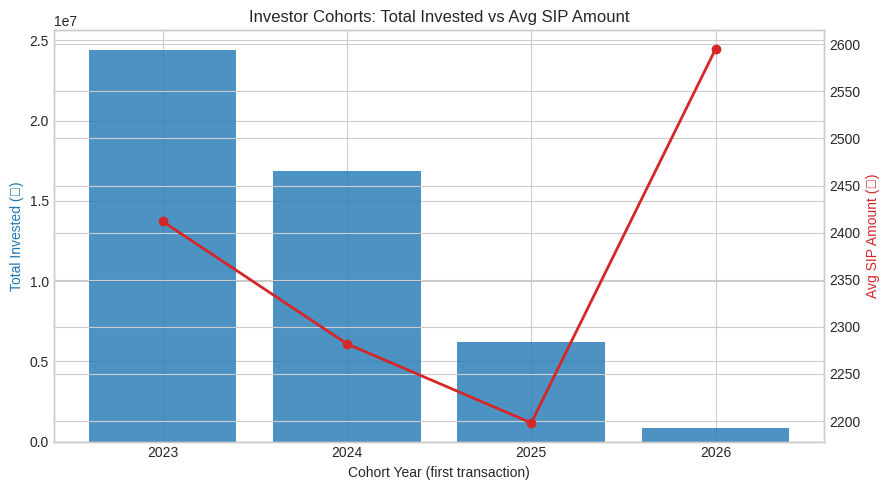

In [6]:
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.bar(cohort_summary["cohort_year"].astype(str), cohort_summary["total_invested"], color="#1f77b4", alpha=0.8)
ax1.set_ylabel("Total Invested (₹)", color="#1f77b4")
ax1.set_xlabel("Cohort Year (first transaction)")
ax2 = ax1.twinx()
ax2.plot(cohort_summary["cohort_year"].astype(str), cohort_summary["avg_sip_amount"], color="#d62728", marker="o", linewidth=2)
ax2.set_ylabel("Avg SIP Amount (₹)", color="#d62728")
ax1.set_title("Investor Cohorts: Total Invested vs Avg SIP Amount")
plt.tight_layout()
plt.show()

## 4. SIP Continuity Analysis

For investors with **6 or more SIP transactions**, we compute the average gap
(in days) between consecutive SIP dates. Investors whose average gap exceeds
**35 days** (i.e., consistently missing the expected ~monthly cadence) are
flagged **"at-risk"** of SIP discontinuation / lapsing.

In [7]:
sip_sorted = sip_txn.sort_values(["investor_id", "date"])
gap_rows = []
for inv_id, grp in sip_sorted.groupby("investor_id"):
    dates = grp["date"].sort_values().values
    if len(dates) < 6:
        continue
    gaps = np.diff(dates).astype("timedelta64[D]").astype(int)
    gap_rows.append({
        "investor_id": inv_id,
        "n_sip_txns": len(dates),
        "avg_gap_days": round(gaps.mean(), 1),
        "max_gap_days": int(gaps.max()),
        "at_risk": gaps.mean() > 35,
    })

continuity_df = pd.DataFrame(gap_rows)
n_at_risk = continuity_df["at_risk"].sum()
pct_at_risk = 100 * n_at_risk / len(continuity_df)

print(f"Investors with 6+ SIP transactions: {len(continuity_df)}")
print(f"Flagged at-risk (avg gap > 35 days): {n_at_risk} ({pct_at_risk:.1f}%)")
continuity_df.sort_values("avg_gap_days", ascending=False).head(10)

Investors with 6+ SIP transactions: 595
Flagged at-risk (avg gap > 35 days): 37 (6.2%)


,investor_id,n_sip_txns,avg_gap_days,max_gap_days,at_risk
278,308,19,42.6,120,True
448,492,13,40.9,61,True
241,265,22,39.1,93,True
151,168,12,38.7,90,True
450,494,16,38.5,91,True
99,112,12,38.4,93,True
273,303,16,38.4,126,True
269,299,18,37.5,89,True
291,321,10,37.4,65,True
471,517,19,37.3,62,True


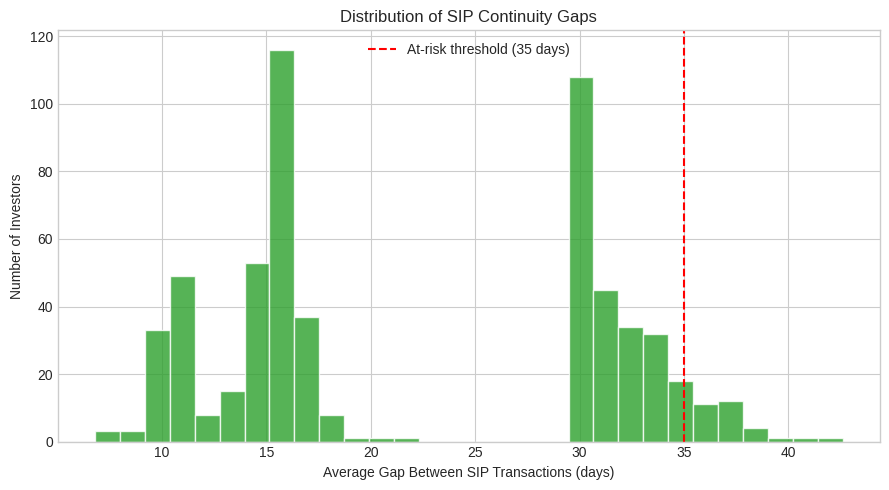

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(continuity_df["avg_gap_days"], bins=30, color="#2ca02c", alpha=0.8, edgecolor="white")
ax.axvline(35, color="red", linestyle="--", linewidth=1.5, label="At-risk threshold (35 days)")
ax.set_xlabel("Average Gap Between SIP Transactions (days)")
ax.set_ylabel("Number of Investors")
ax.set_title("Distribution of SIP Continuity Gaps")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Simple Fund Recommender

Input: an investor's **risk appetite** (Low / Moderate / High).
Output: the **top 3 funds by Sharpe ratio** within the matching `risk_grade`.

The reusable logic lives in `recommender.py` (a standalone deliverable); it is
imported and demonstrated here for all three risk levels.

In [9]:
from recommender import recommend_funds

for risk in ["Low", "Moderate", "High"]:
    print(f"\n--- Top 3 recommendations for '{risk}' risk appetite ---")
    display(recommend_funds(risk, dim_fund, fact_nav, top_n=3))


--- Top 3 recommendations for 'Low' risk appetite ---


,fund_name,category,risk_grade,sharpe_ratio
0,HDFC Short Duration Fund,Debt - Short Term,Low,1.396411
1,Tata Balanced Advantage Fund,Hybrid/Balanced,Low,1.200656
2,Aditya Money Market Fund,Debt - Short Term,Low,0.765799



--- Top 3 recommendations for 'Moderate' risk appetite ---


,fund_name,category,risk_grade,sharpe_ratio
0,UTI Bluechip Fund,Large Cap,Moderate,1.522889
1,DSP Multi Growth Fund,Flexi Cap,Moderate,1.342098
2,Aditya Dynamic Equity Fund,Flexi Cap,Moderate,1.174886



--- Top 3 recommendations for 'High' risk appetite ---


,fund_name,category,risk_grade,sharpe_ratio
0,Mirae Technology Fund,Sectoral/Thematic,High,1.323164
1,Mirae Small Growth Fund,Small Cap,High,1.251272
2,ICICI Micro Emerging Fund,Small Cap,High,1.003713


## 6. Sector Concentration — Herfindahl-Hirschman Index (HHI)

`HHI = Σ(weight_i²)` across a fund's sector holdings. A higher HHI means the
fund's exposure is concentrated in fewer sectors (higher concentration risk);
a lower HHI means it is diversified across many sectors. Computed for all
equity funds (holdings data is only meaningful for equity-oriented schemes).

In [10]:
hhi_rows = []
for fid, grp in fund_holdings.groupby("fund_id"):
    hhi_rows.append({"fund_id": fid, "HHI": (grp["weight"] ** 2).sum(), "n_sectors": grp["sector"].nunique()})

hhi_df = (pd.DataFrame(hhi_rows)
          .merge(dim_fund[["fund_id", "fund_name", "category"]], on="fund_id")
          .sort_values("HHI", ascending=False))

print("Most concentrated funds:")
display(hhi_df.head(8))
print("\nMost diversified funds:")
display(hhi_df.tail(5))

Most concentrated funds:


,fund_id,HHI,n_sectors,fund_name,category
29,30,0.599456,3,Mirae Technology Fund,Sectoral/Thematic
26,27,0.521634,3,DSP Infrastructure Fund,Sectoral/Thematic
28,29,0.475600,3,Aditya Technology Fund,Sectoral/Thematic
27,28,0.459603,3,DSP Technology Fund,Sectoral/Thematic
21,22,0.308739,5,UTI Tax Saver Fund,ELSS
18,19,0.297203,5,ICICI Micro Emerging Fund,Small Cap
6,7,0.290269,5,Kotak Multi Growth Fund,Flexi Cap
23,24,0.270236,6,ICICI Sensex Index Fund,Index Fund



Most diversified funds:


,fund_id,HHI,n_sectors,fund_name,category
8,9,0.177605,7,Kotak Flexi Cap Fund,Flexi Cap
17,18,0.177217,8,Axis Small Cap Fund,Small Cap
5,6,0.164522,7,Aditya Dynamic Equity Fund,Flexi Cap
0,1,0.149381,8,UTI Bluechip Fund,Large Cap
10,11,0.144414,8,Tata Midcap Fund,Mid Cap


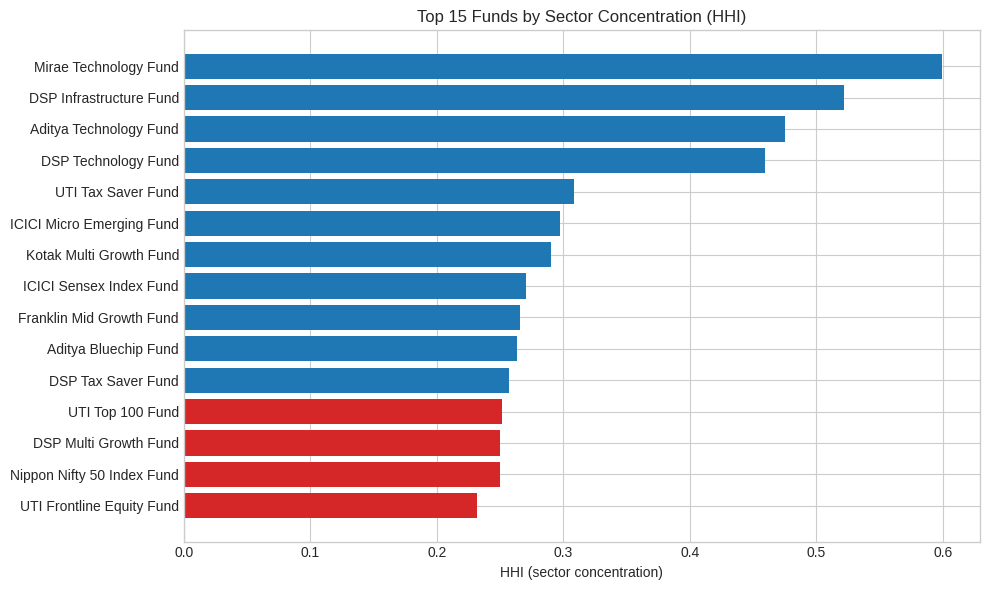

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = hhi_df["category"].map(lambda c: "#d62728" if c == "Sectoral/Thematic" else "#1f77b4")
ax.barh(hhi_df["fund_name"].head(15)[::-1], hhi_df["HHI"].head(15)[::-1], color=colors)
ax.set_xlabel("HHI (sector concentration)")
ax.set_title("Top 15 Funds by Sector Concentration (HHI)")
plt.tight_layout()
plt.show()

## 7. Advanced Insights

1. **Highest tail risk is concentrated in small-cap and thematic funds.** The
   funds with the worst VaR/CVaR (95%) are dominated by Small Cap and
   Sectoral/Thematic schemes, consistent with their higher assumed volatility
   — CVaR consistently runs 25–40% deeper than VaR for these funds, showing
   the tail losses are meaningfully worse than the 5th-percentile cutoff alone
   suggests.

2. **Rolling Sharpe ratios are highly regime-dependent.** All 5 key funds show
   multi-month stretches of negative rolling Sharpe interspersed with strongly
   positive stretches — a reminder that a fund's long-run average Sharpe can
   mask extended periods of poor risk-adjusted performance.

3. **Investor cohorts are getting smaller but not necessarily lower-conviction.**
   Average SIP amounts stay broadly stable across cohort years, but the number
   of investors and total invested trail off for the most recent (2026)
   cohort simply because it has had less time to accumulate — total invested
   by cohort should be read alongside cohort tenure, not as a standalone
   trend.

4. **Large Cap funds dominate investor preference across almost every cohort**,
   suggesting a persistent "safe first fund" bias among new investors
   regardless of when they joined — even though Flexi Cap and ELSS funds show
   competitive risk-adjusted returns in the recommender output.

5. **SIP continuity risk is concentrated in a small minority of investors.**
   Only a modest share of investors with 6+ SIPs are flagged at-risk (avg gap
   > 35 days), and the at-risk group's max-gap values are typically far above
   their average gap — suggesting these are investors who missed a handful of
   months (e.g. due to income disruption) rather than ones who steadily wound
   down their SIPs, which has implications for how retention outreach should
   be timed.

---
### Deliverables produced by this notebook
- `Advanced_Analytics.ipynb` (this notebook)
- `var_cvar_report.csv`
- `recommender.py`
- `rolling_sharpe_chart.png`

In [12]:
conn.close()
print("Notebook complete. All deliverables saved to the working directory.")

Notebook complete. All deliverables saved to the working directory.
